<a href="https://colab.research.google.com/github/Arif0000/Pytorch/blob/main/Optimauzation_using_optuna_pytoch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [42]:
torch.manual_seed(42)

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [44]:
df = pd.read_csv('/content/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,0,0,105,92,101,107,100,132,0,0,2,4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,150,...,211,220,214,74,0,255,222,128,0,0,0,0,0,0,0,0,0,44,12,0,0,40,134,162,191,214,163,146,165,79,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,0,114,183,112,55,23,72,102,165,160,28,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,24,188,163,93,...,171,249,207,197,202,45,0,3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,22,21,25,69,52,45,74,39,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,0,0,0,46,0,21,68,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25,187,189,...,230,237,229,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68,116,112,136,147,144,121,102,63,0,0,0,0,0,0,0,0,0,0


In [45]:
df.shape

(60000, 785)

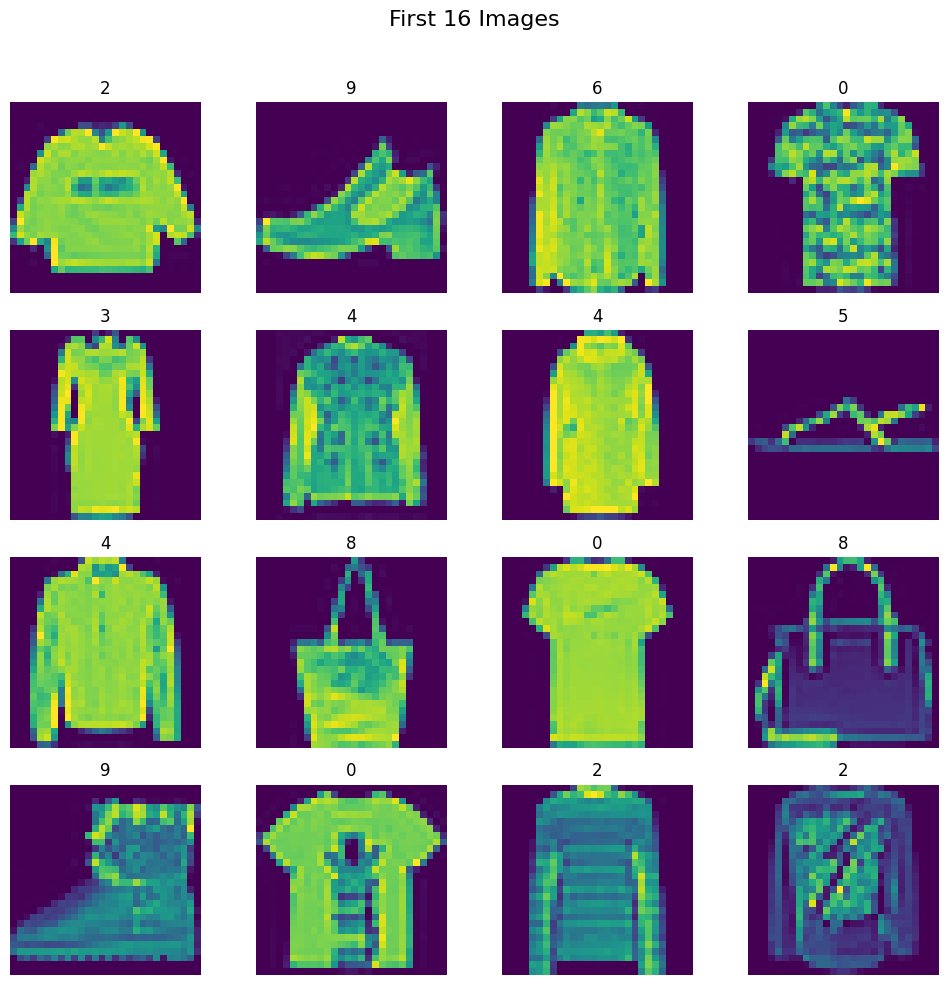

In [46]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(df.iloc[i,0])
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [47]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [49]:
X_train = X_train/255.0
X_test = X_test/255.0

In [50]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)
  def __len__(self):
    return len(self.features)
  def __getitem__(self, index):
    return self.features[index], self.labels[index]


In [51]:
train_dataset = CustomDataset(X_train,y_train)

In [52]:
test_dataset = CustomDataset(X_test, y_test)

In [53]:
class MyNN(nn.Module):
  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer,dropout_rate):
    super().__init__()
    layers = []
    for i in range(num_hidden_layers):
      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))
      input_dim = neurons_per_layer
    layers.append(nn.Linear(neurons_per_layer,output_dim))
    self.model = nn.Sequential(*layers)
  def forward(self, x):
    return self.model(x)

In [54]:
from torch.optim import optimizer
def objective(trail):
  num_hidden_layers = trail.suggest_int('num_hidden_layer', 1,5)
  neirons_per_layer = trail.suggest_int('neurons_per_layer', 8,128, step=8)
  epochs = trail.suggest_int('epochs', 10,50,step=10)
  learning_rate = trail.suggest_float('learning_rate', 1e-5,1e-1, log=True)
  dropout_rate = trail.suggest_float('dropout_rate', 0.1,0.5,step=0.1)
  batch_size = trail.suggest_categorical('batch_size',[16,32,64,128])
  optimizer_name = trail.suggest_categorical('optimizer',['Adam','SGD','RMSprop'])
  weight_decay = trail.suggest_float('weight_decay',1e-5,1e-3,log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
  model.to(device)

  criterion = nn.CrossEntropyLoss()
  optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4)

  if optimizer_name == "Adam":
    optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optim.SGD(model.parameters(), lr = learning_rate, weight_decay= weight_decay)
  else:
    optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

  for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
      outputs = model(batch_features)
      loss = criterion(outputs, batch_labels)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
  model.eval()
  total = 0
  correct = 0
  with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

      outputs = model(batch_features)
      _, predicted = torch.max(outputs,1)
      total = total + batch_labels.shape[0]
      correct = correct + (predicted == batch_labels).sum().item()
    accuracy = correct / total
  return accuracy

In [55]:
!pip install optuna

In [56]:
import optuna

In [57]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

[I 2026-03-04 20:28:20,702] A new study created in memory with name: no-name-f432d482-4595-459a-b697-a260451ba41f
[W 2026-03-04 20:28:20,707] Trial 0 failed with parameters: {'num_hidden_layer': 3, 'neurons_per_layer': 128, 'epochs': 20, 'learning_rate': 0.04632171220904431, 'dropout_rate': 0.2, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 3.5714876169353674e-05} because of the following error: NameError("name 'neurons_per_layer' is not defined").
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1009/3863358440.py", line 18, in objective
    model = MyNN(input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate)
                                                           ^^^^^^^^^^^^^^^^^
NameError: name 'neurons_per_layer' is not defined. Did you mean: 'neirons_per_layer'?
[W 2026-03-04 

NameError: name 'neurons_per_layer' is not defined

In [ ]:
study.best_value

In [ ]:
study.best_params